## 2D error heatmap generator

In [1]:
%%capture
%pip install matplotlib==3.5.2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import display
import os
from math import *

# use latin modern math font
if not os.path.isfile('latinmodern-math.otf'):
    !wget https://github.com/cathaypacific8747/physics-ia-tools/raw/main/latinmodern-math.otf
matplotlib.font_manager.fontManager.addfont('latinmodern-math.otf')
plt.rcParams["font.family"] = "Latin Modern Math"
plt.rcParams["mathtext.fontset"] = "cm"
plt.ioff()

class Graph:
    def __init__(self, xRange, yRange, xDivisions, yDivisions, zFunc):
        self.x = np.linspace(xRange[0], xRange[1], xDivisions)
        self.y = np.linspace(yRange[0], yRange[1], yDivisions)
        self.xg, self.yg = np.meshgrid(self.x, self.y)
        self.zg = np.array([[min(zFunc(self.x[xi], self.y[yi]), 1) for yi in range(len(self.y))] for xi in range(len(self.x))])

    def generate(self, xLabel, yLabel, colourBarLabel, contourLineLevels):
        contour = plt.contourf(self.x, self.y, self.zg, 500, cmap='viridis')
        if contourLineLevels:
            contourLine = plt.contour(self.x, self.y, self.zg, levels=contourLineLevels, colors='white', linewidths=0.4)
            plt.clabel(contourLine, inline=True, fontsize=6)
            cbar = plt.colorbar(contour)
            cbar.set_label(colourBarLabel)
        else:
            cbar = plt.colorbar(contour)
            cbar.set_label(colourBarLabel)
        plt.xlabel(xLabel)
        plt.ylabel(yLabel)
        plt.savefig('graph.jpg', dpi=600)
        plt.clf()
        plt.close()
        return Image.open('graph.jpg')

/var/folders/ht/7rs593hn3kl_sc6g4gdhk3v40000gn/T/ipykernel_54726/1108040967.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.0001/0.1000 + 2*0.01/x + 0.0005/y


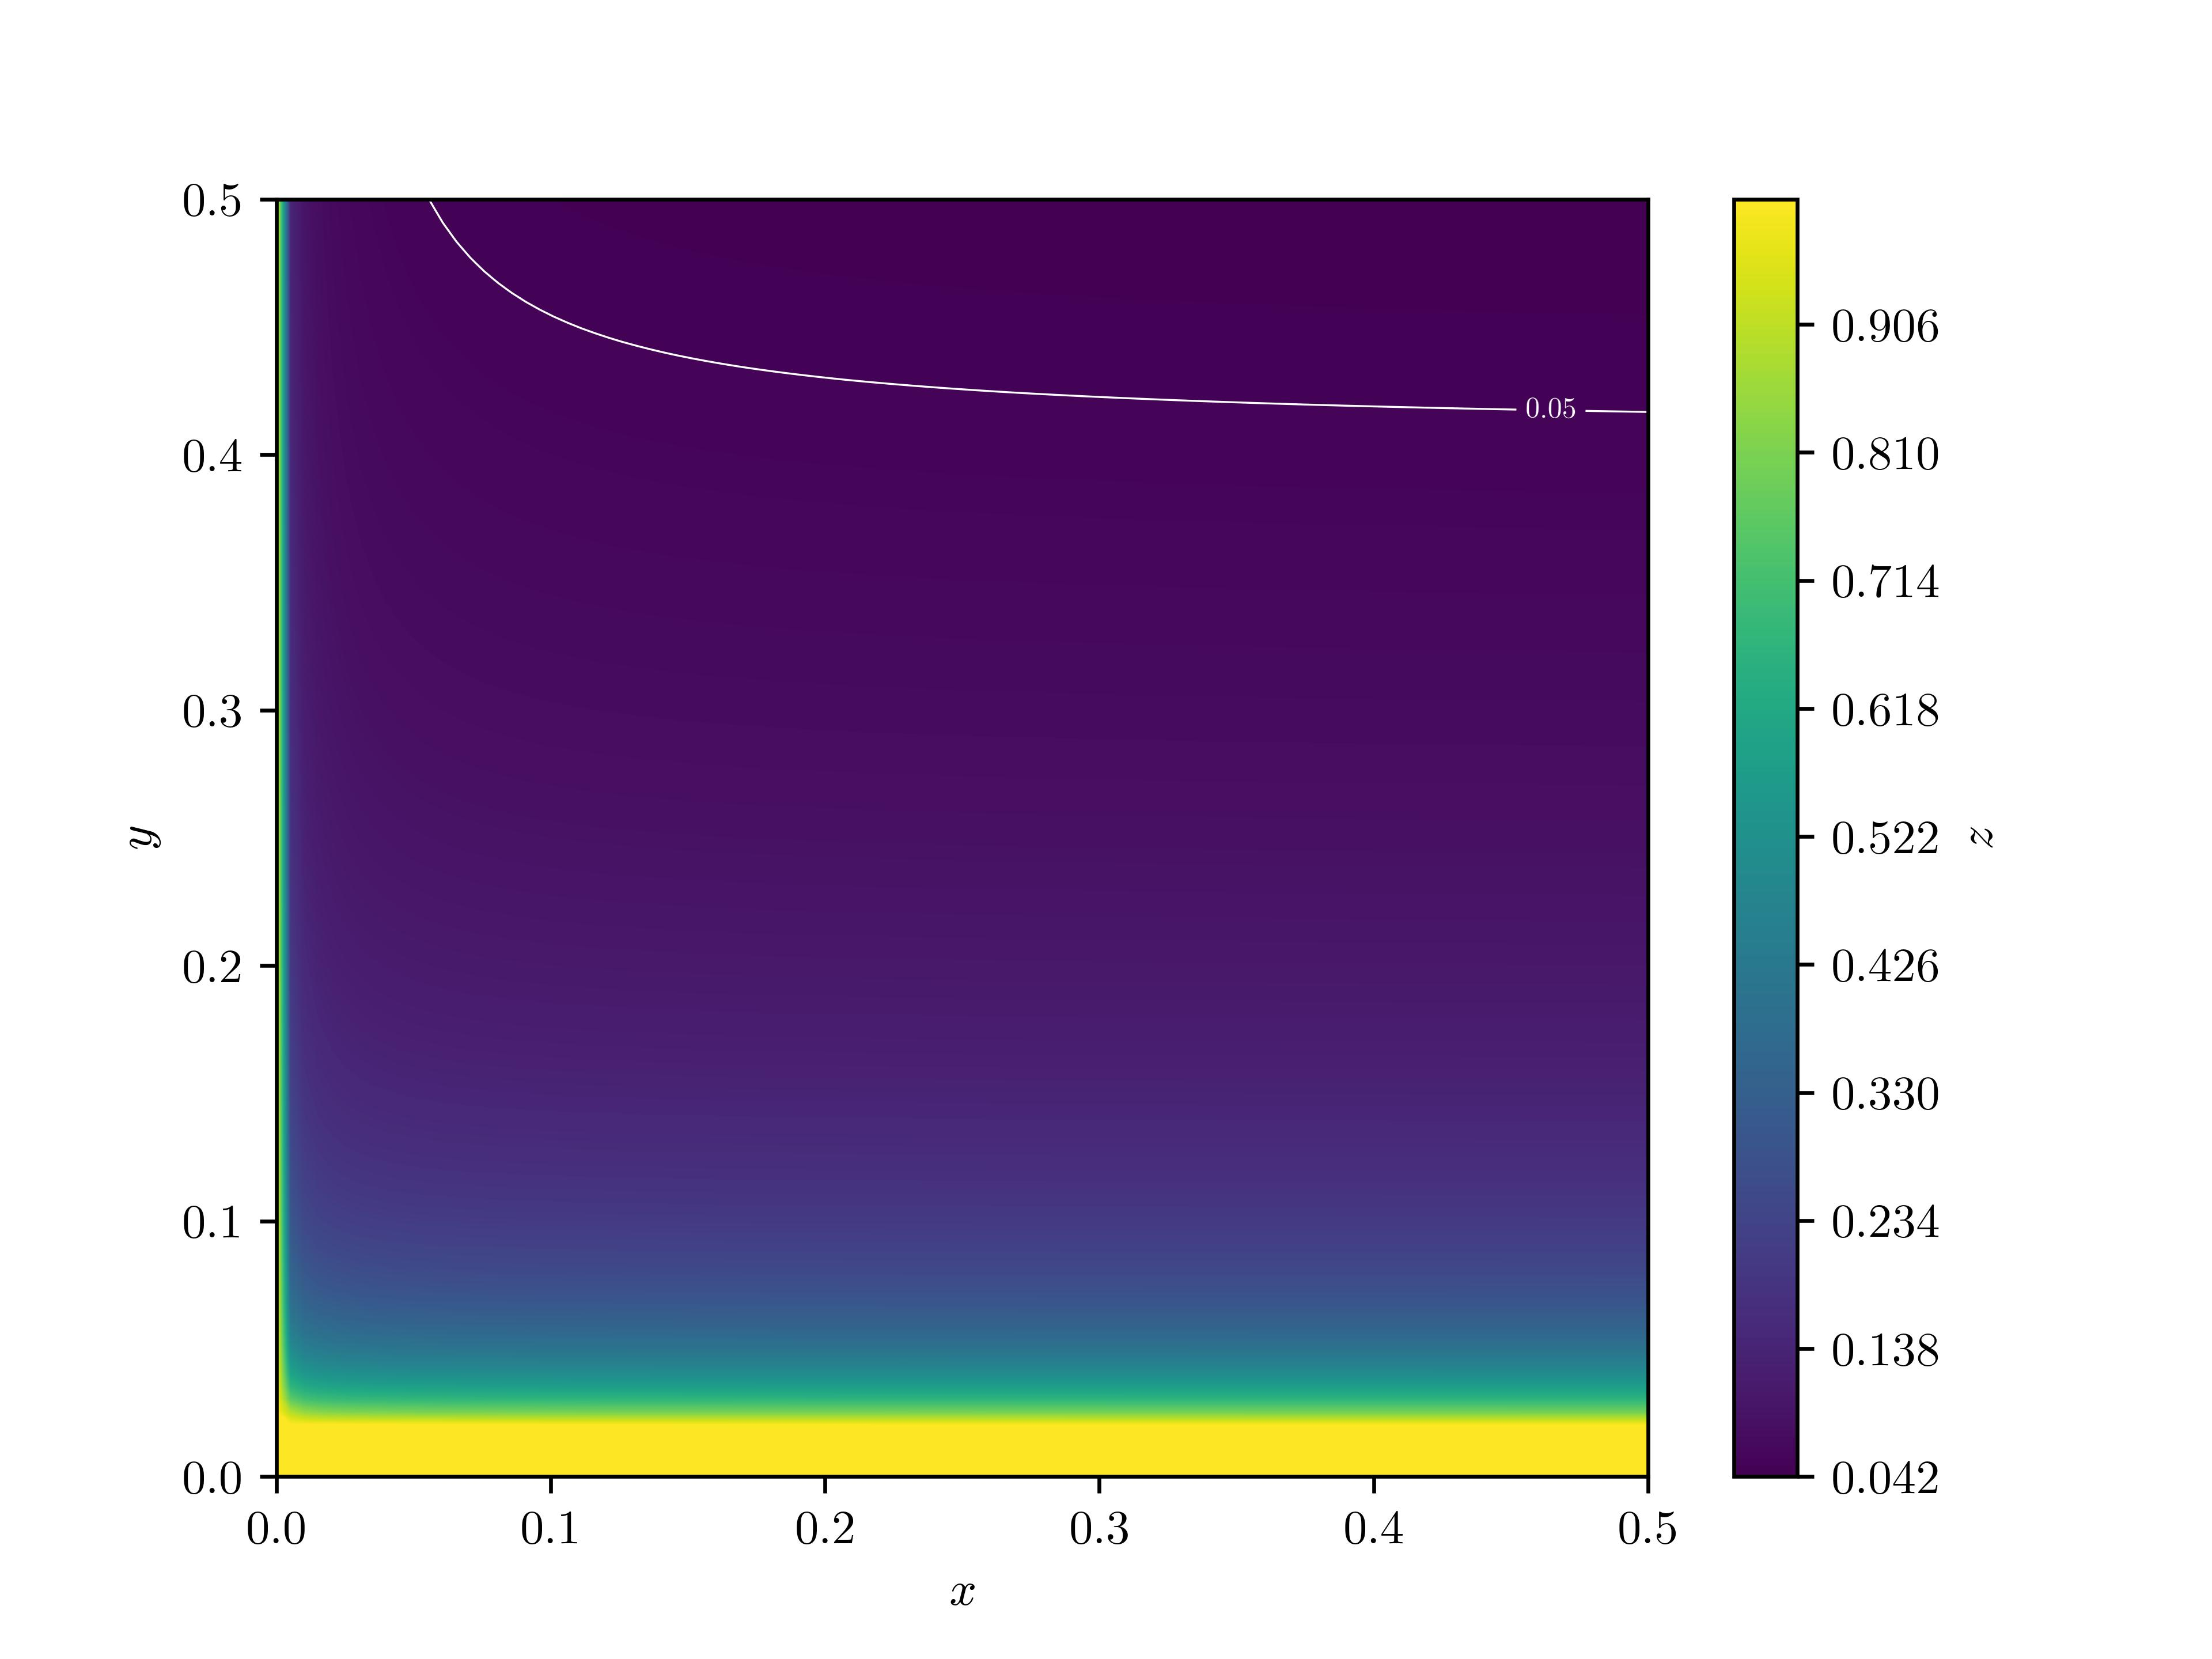

In [2]:
xRange = (0, 0.5)
yRange = (0, 0.5)
xDivisions = 100
yDivisions = 100
xLabel = '$x$'
yLabel = '$y$'
colourBarLabel = '$z$'
contourLineLevels = [0.05] # leave empty to disable

def z(x, y):
    return 0.0001/0.1000 + 2*0.01/x + 0.0005/y

graph = Graph(xRange, yRange, xDivisions, yDivisions, z)
display(graph.generate(xLabel, yLabel, colourBarLabel, contourLineLevels))